# Bootstrap Confidence Intervals for Test-Set Accuracy
Reuses cached prediction probabilities -- no models, no GPU needed. Resamples
the test set with replacement 2,000 times to estimate a 95% confidence
interval around each model's reported accuracy, quantifying how much the
accuracy estimate could plausibly vary due to test-set sampling alone.

Note: this addresses sampling variance WITHIN the existing test set. It does
NOT replace k-fold cross-validation across different train/val/test splits,
which would require retraining every model from scratch.

## Cell 1 — Setup + load cached predictions

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')

print("Loaded. Test set size:", len(true_labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded. Test set size: 2538


## Cell 2 — Bootstrap function
Draws N_BOOTSTRAP resamples (with replacement, same size as the test set),
computes accuracy on each, and returns the resulting distribution.

In [13]:
N_BOOTSTRAP = 2000
RNG = np.random.default_rng(42)

def bootstrap_accuracy(probs, true_labels, n_bootstrap=N_BOOTSTRAP):
    pred_labels = np.argmax(probs, axis=1)
    correct = (pred_labels == true_labels).astype(float)
    n = len(correct)
    boot_accs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = RNG.integers(0, n, size=n)
        boot_accs[i] = correct[idx].mean()
    point_estimate = correct.mean()
    ci_low, ci_high = np.percentile(boot_accs, [2.5, 97.5])
    return point_estimate, ci_low, ci_high, boot_accs

print("Bootstrap function ready")

Bootstrap function ready


## Cell 3 — Run bootstrap for all 7 models, build summary table

In [14]:
all_models = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

rows = []
boot_distributions = {}
for name, probs in all_models.items():
    point, lo, hi, dist = bootstrap_accuracy(probs, true_labels)
    boot_distributions[name] = dist
    rows.append({
        "Model": name,
        "Accuracy": round(point * 100, 2),
        "95% CI Lower": round(lo * 100, 2),
        "95% CI Upper": round(hi * 100, 2),
        "CI Width": round((hi - lo) * 100, 2),
    })

ci_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print(ci_df.to_string(index=False))

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
ci_df.to_csv(f'{output_folder}/bootstrap_confidence_intervals.csv', index=False)
print(f"\nSaved to: {output_folder}/bootstrap_confidence_intervals.csv")

            Model  Accuracy  95% CI Lower  95% CI Upper  CI Width
Proposed Ensemble     98.86         98.42         99.25      0.83
             Swin     98.42         97.91         98.86      0.95
              ViT     98.23         97.68         98.74      1.06
         ResNet50     97.95         97.40         98.50      1.10
   EfficientNetB0     97.68         97.04         98.23      1.18
      DenseNet121     96.89         96.18         97.56      1.38
            LeViT     95.15         94.33         95.98      1.66

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/bootstrap_confidence_intervals.csv


## Cell 4 — Check whether the proposed ensemble's CI overlaps each baseline's CI
Non-overlapping intervals are strong (though informal) visual evidence that
the difference is not just sampling noise -- complementing the McNemar's
test already reported.

In [15]:
ens_lo = ci_df.loc[ci_df["Model"] == "Proposed Ensemble", "95% CI Lower"].values[0]
ens_hi = ci_df.loc[ci_df["Model"] == "Proposed Ensemble", "95% CI Upper"].values[0]
print(f"Proposed Ensemble 95% CI: [{ens_lo:.2f}, {ens_hi:.2f}]")
print()
for _, row in ci_df.iterrows():
    if row["Model"] == "Proposed Ensemble":
        continue
    overlaps = row["95% CI Upper"] >= ens_lo
    status = "OVERLAPS" if overlaps else "does NOT overlap (stronger evidence)"
    print(f"  vs {row['Model']:16s} CI=[{row['95% CI Lower']:.2f}, {row['95% CI Upper']:.2f}]  -> {status}")

Proposed Ensemble 95% CI: [98.42, 99.25]

  vs Swin             CI=[97.91, 98.86]  -> OVERLAPS
  vs ViT              CI=[97.68, 98.74]  -> OVERLAPS
  vs ResNet50         CI=[97.40, 98.50]  -> OVERLAPS
  vs EfficientNetB0   CI=[97.04, 98.23]  -> does NOT overlap (stronger evidence)
  vs DenseNet121      CI=[96.18, 97.56]  -> does NOT overlap (stronger evidence)
  vs LeViT            CI=[94.33, 95.98]  -> does NOT overlap (stronger evidence)


## Cell 5 — Visualization: accuracy with 95% CI error bars

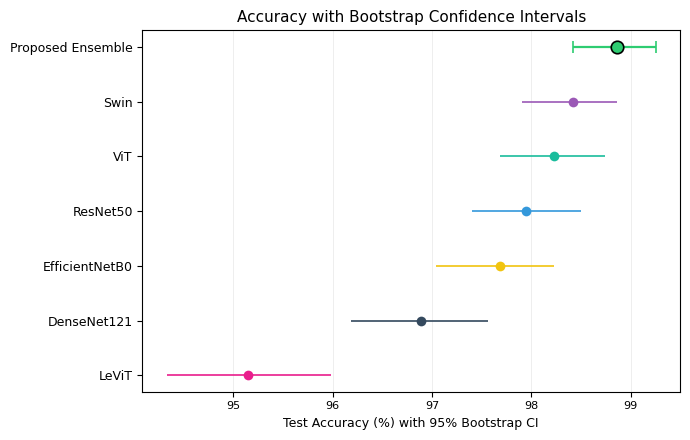

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/bootstrap_ci_chart.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = ci_df.iloc[::-1]  # reverse so best is on top
y = np.arange(len(plot_df))

# distinct color per model — "Proposed Ensemble" kept as the highlight color
model_colors = {
  "Proposed Ensemble": "#2ECC71",   # bright green
"Swin":               "#9B59B6",  # bright purple
"ViT":                "#1ABC9C",  # bright teal
"ResNet50":           "#3498DB",  # bright blue
"EfficientNetB0":     "#F1C40F",  # golden yellow
"DenseNet121":        "#34495E",  # dark navy/slate
"LeViT":              "#E91E8C",  # bright pink

}

# plot each model separately so its marker + error bar share one color
for yi, (_, row) in zip(y, plot_df.iterrows()):
    color = model_colors.get(row["Model"], "#8C8C8C")
    is_proposed = row["Model"] == "Proposed Ensemble"
    ax.errorbar(
        row["Accuracy"], yi,
        xerr=[[row["Accuracy"] - row["95% CI Lower"]], [row["95% CI Upper"] - row["Accuracy"]]],
        fmt='o', capsize=4, color=color, ecolor=color,
        markersize=9 if is_proposed else 7,
        markeredgecolor='black' if is_proposed else 'none',
        markeredgewidth=1.2 if is_proposed else 0,
        zorder=3, elinewidth=1.6 if is_proposed else 1.2
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Model"], fontsize=9)
ax.set_xlabel('Test Accuracy (%) with 95% Bootstrap CI', fontsize=9)
ax.set_title('Accuracy with Bootstrap Confidence Intervals', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{output_folder}/bootstrap_ci_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/bootstrap_ci_chart.png")